# 🌊 Rising Waters - AI Powered Flood Prediction System

## Importing Required Libraries

This notebook develops a machine learning model to predict flood occurrence based on environmental and weather-related features.

In [ ]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# Reading the Dataset

In [4]:
# Read the training dataset

df = pd.read_csv("../../dataset/train.csv")

print("✅ Dataset Loaded Successfully!")

✅ Dataset Loaded Successfully!


# Display Dataset

In [5]:
df.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


# Dataset Shape

In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1117957, 22)


# Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  1117957 non-null 

# Statistical Summary

In [8]:
df.describe()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,...,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06,1.117957e+06
mean,5.589780e+05,4.921450e+00,4.926671e+00,4.955322e+00,4.942240e+00,4.942517e+00,4.934093e+00,4.955878e+00,4.927791e+00,4.942619e+00,...,4.946893e+00,4.953999e+00,4.931376e+00,4.929032e+00,4.925907e+00,4.927520e+00,4.950859e+00,4.940587e+00,4.939004e+00,5.044803e-01
std,3.227265e+05,2.056387e+00,2.093879e+00,2.072186e+00,2.051689e+00,2.083391e+00,2.057742e+00,2.083063e+00,2.065992e+00,2.068545e+00,...,2.072333e+00,2.088899e+00,2.078287e+00,2.082395e+00,2.064813e+00,2.074176e+00,2.068696e+00,2.081123e+00,2.090350e+00,5.102610e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.850000e-01
25%,2.794890e+05,3.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,...,4.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,3.000000e+00,4.700000e-01
50%,5.589780e+05,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.050000e-01
75%,8.384670e+05,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,...,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,5.400000e-01
max,1.117956e+06,1.600000e+01,1.800000e+01,1.600000e+01,1.700000e+01,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.600000e+01,...,1.700000e+01,1.700000e+01,1.600000e+01,1.600000e+01,1.700000e+01,1.800000e+01,1.900000e+01,1.600000e+01,1.600000e+01,7.250000e-01


# Univariate Analysis

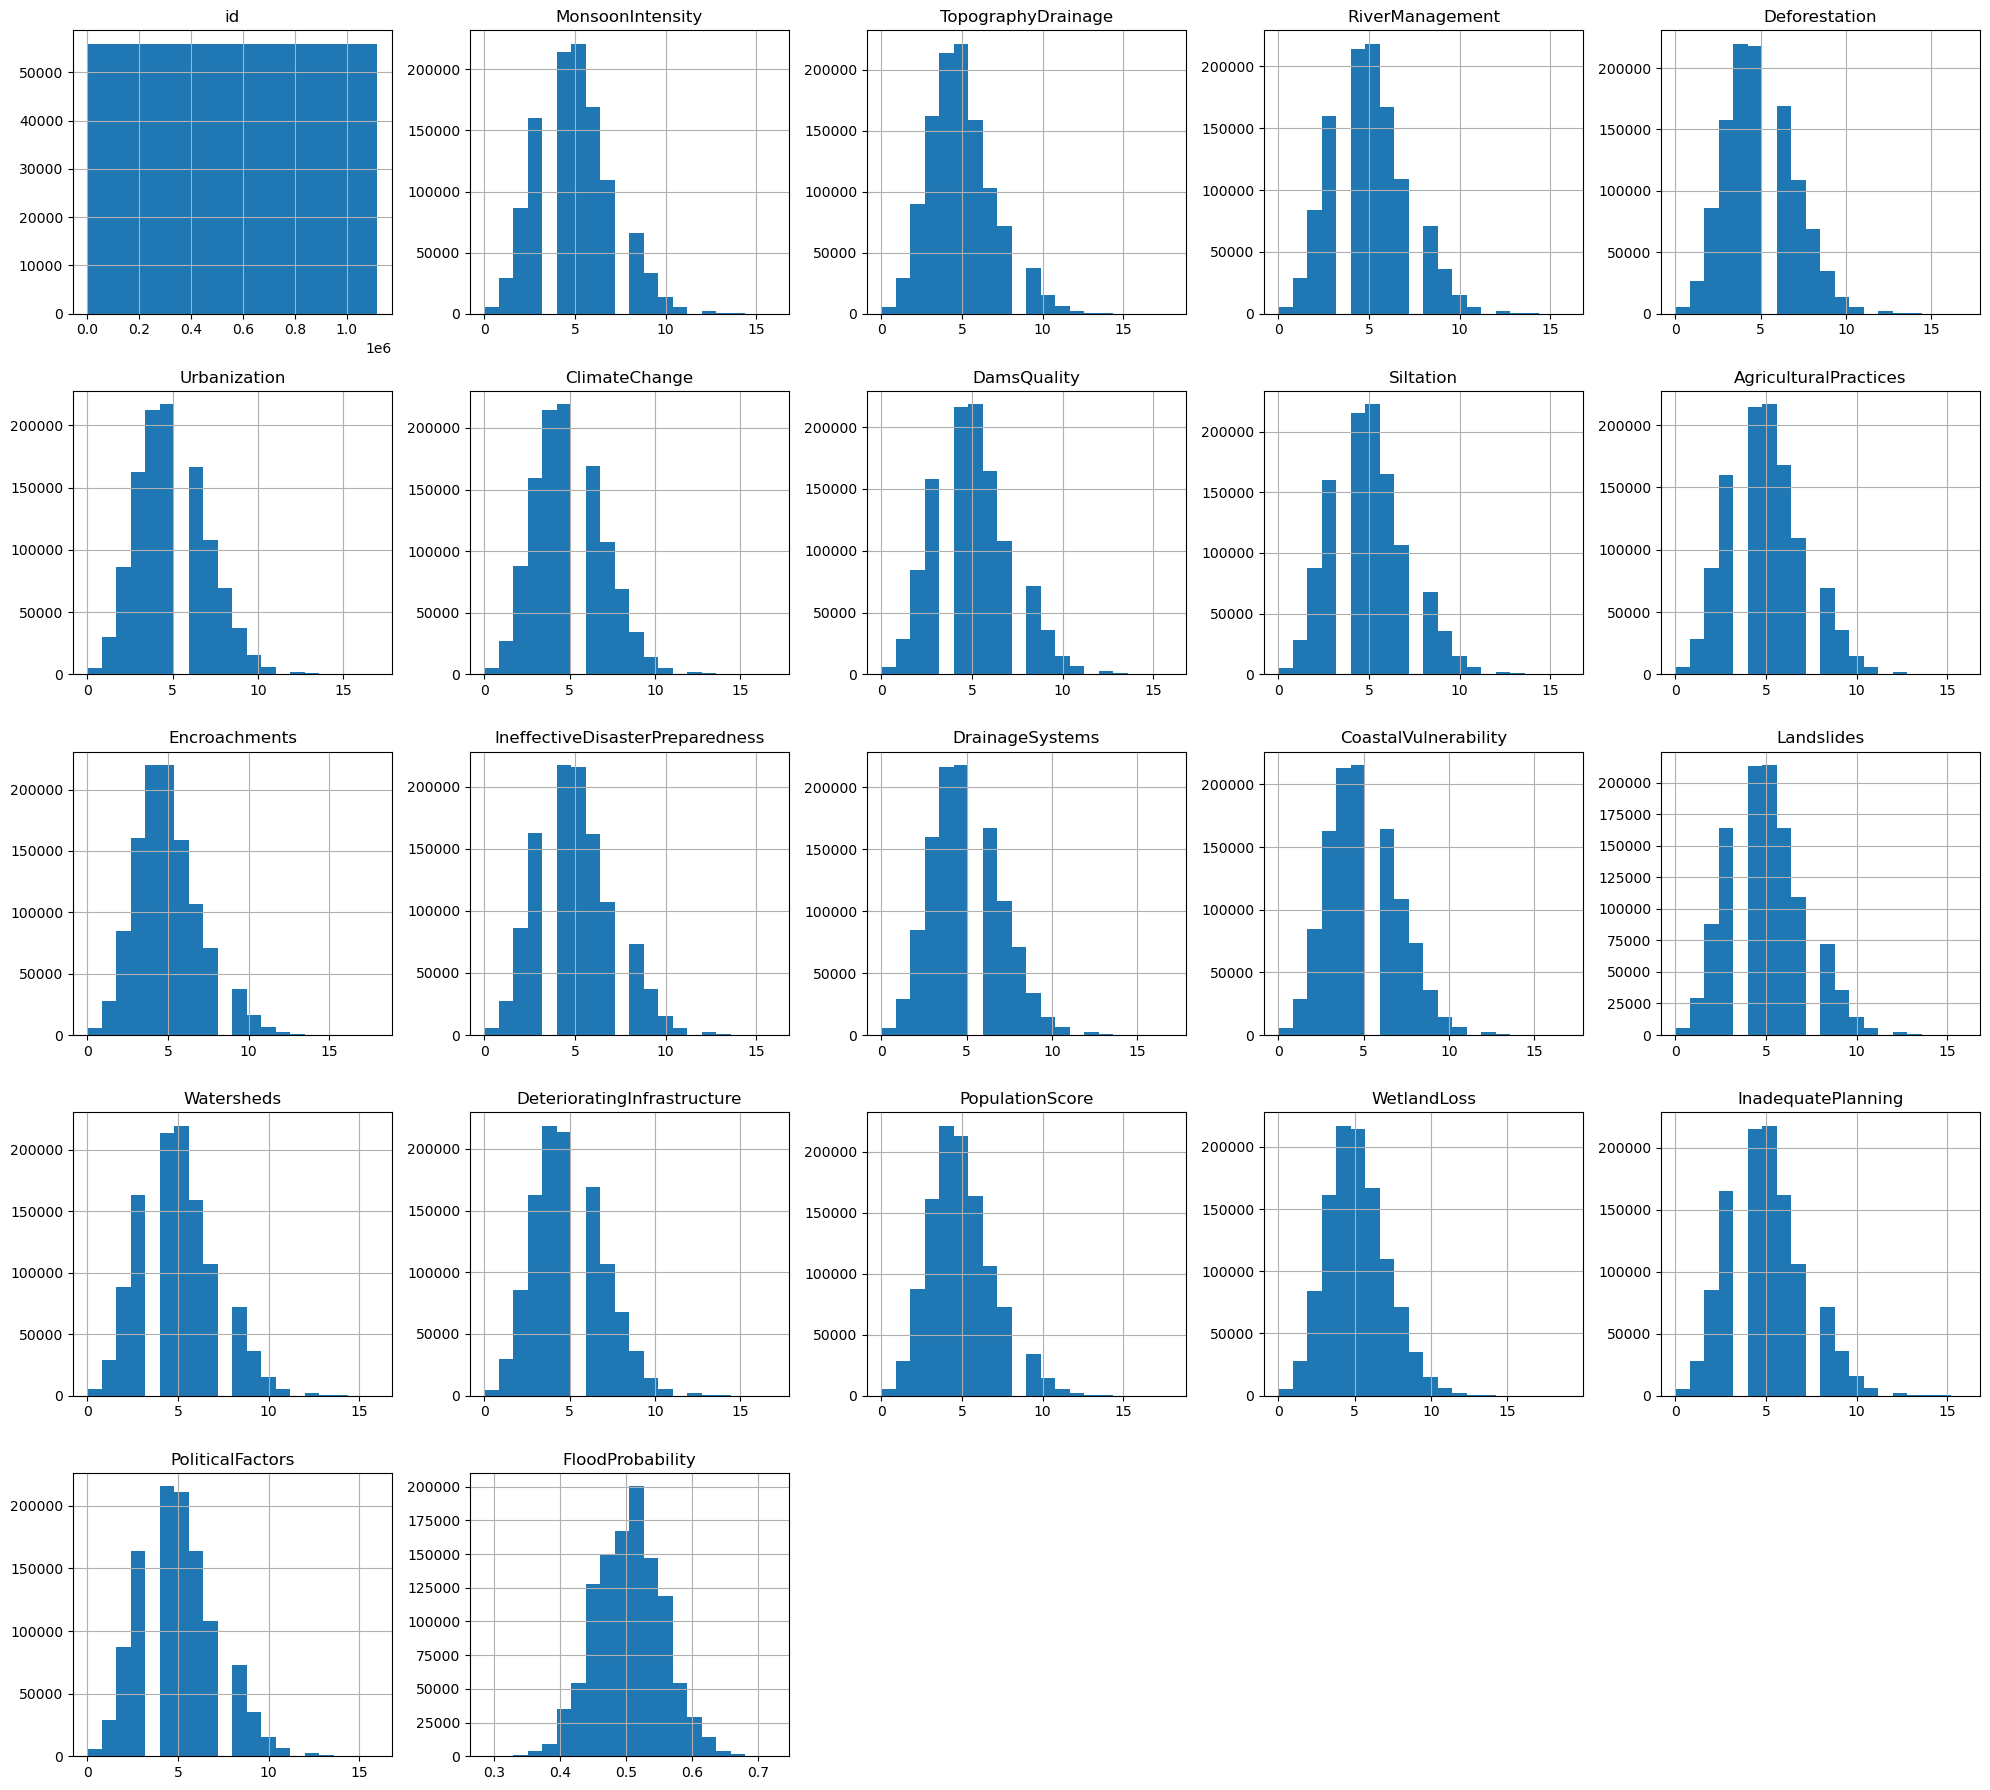

In [9]:
# Plot distribution of all numerical features

df.hist(figsize=(20,18), bins=20)

plt.tight_layout()

plt.show()

# Multivariate Analysis

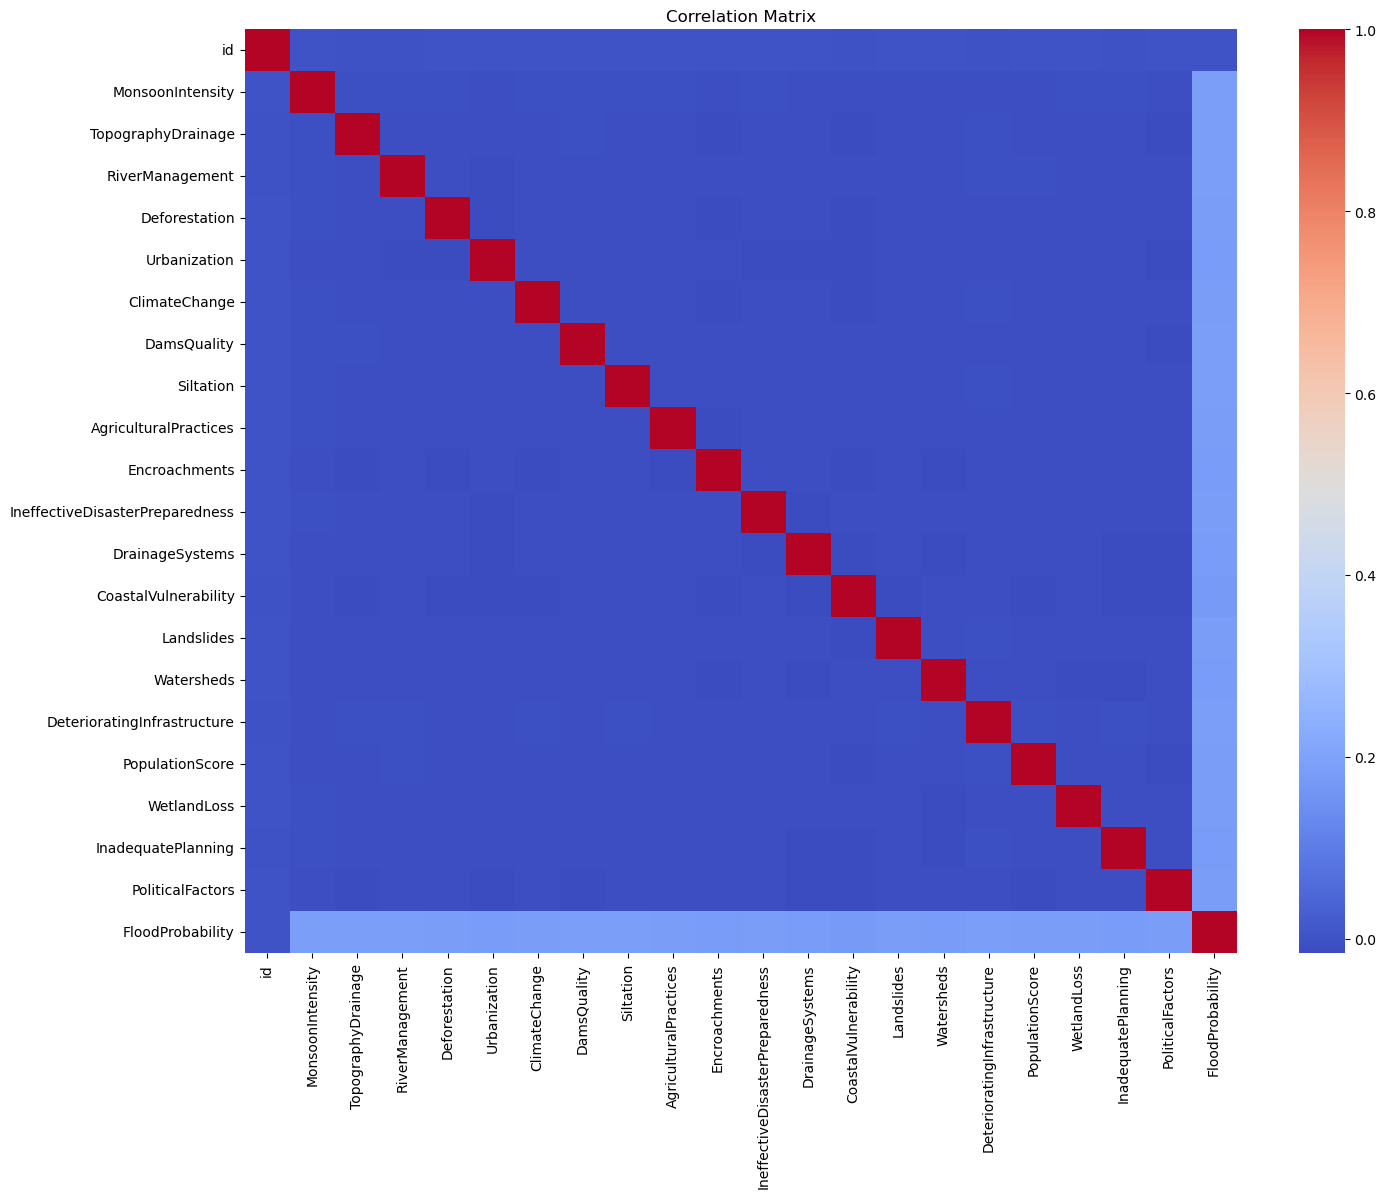

In [10]:
plt.figure(figsize=(16,12))

sns.heatmap(df.corr(),
            cmap="coolwarm",
            annot=False)

plt.title("Correlation Matrix")

plt.show()

# Handling Missing Values

In [11]:
df.isnull().sum()

id                                 0
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

In [12]:
print("Total Missing Values :", df.isnull().sum().sum())

Total Missing Values : 0


# Handling Outliers

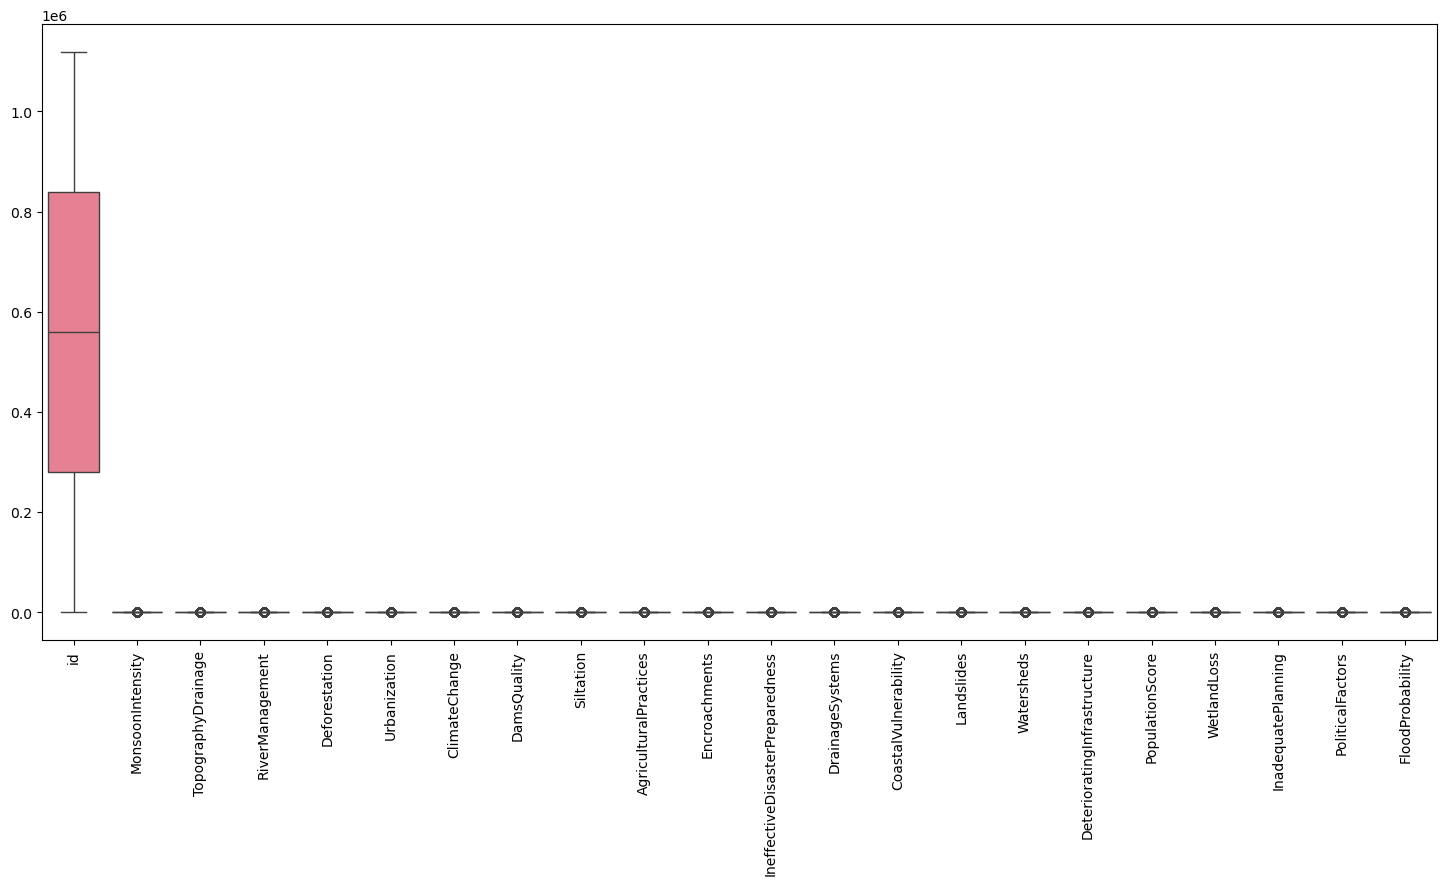

In [13]:
plt.figure(figsize=(18,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

# Handling Categorical Values

In [14]:
print(df.dtypes)

id                                   int64
MonsoonIntensity                     int64
TopographyDrainage                   int64
RiverManagement                      int64
Deforestation                        int64
Urbanization                         int64
ClimateChange                        int64
DamsQuality                          int64
Siltation                            int64
AgriculturalPractices                int64
Encroachments                        int64
IneffectiveDisasterPreparedness      int64
DrainageSystems                      int64
CoastalVulnerability                 int64
Landslides                           int64
Watersheds                           int64
DeterioratingInfrastructure          int64
PopulationScore                      int64
WetlandLoss                          int64
InadequatePlanning                   int64
PoliticalFactors                     int64
FloodProbability                   float64
dtype: object


In [15]:
print("Categorical Columns")

print(df.select_dtypes(include=['object']).columns)

Categorical Columns
Index([], dtype='object')


# Splitting Data into Training and Testing Sets

In [16]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop(["id", "FloodProbability"], axis=1)

# Target
y = df["FloodProbability"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1117957, 20)
Target Shape: (1117957,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (894365, 20)
Testing Data : (223592, 20)


# Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [22]:
import joblib

joblib.dump(scaler, "../../model/scaler.pkl")

['../../model/scaler.pkl']

# Decision Tree Model

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_rmse = mean_squared_error(y_test, y_pred_dt) ** 0.5
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

Decision Tree Results
RMSE: 0.04953202070371992
R2 Score: 0.056113603906863596


# Random Forest Model

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
RMSE: 0.031050224508069227
R2 Score: 0.6290826702639055


# KNN Model

In [29]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_rmse = mean_squared_error(y_test, y_pred_knn) ** 0.5
knn_r2 = r2_score(y_test, y_pred_knn)

print("KNN Results")
print("RMSE:", knn_rmse)
print("R2 Score:", knn_r2)

KNN Results
RMSE: 0.029288008293204555
R2 Score: 0.6699898382858045


# XGBoost Model

In [31]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

xgb_rmse = mean_squared_error(y_test, y_pred_xgb) ** 0.5
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("RMSE:", xgb_rmse)
print("R2 Score:", xgb_r2)

XGBoost Results
RMSE: 0.025036330124841702
R2 Score: 0.7588490516635413


In [32]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],
    "RMSE": [
        dt_rmse,
        rf_rmse,
        knn_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        dt_r2,
        rf_r2,
        knn_r2,
        xgb_r2
    ]
})

results = results.sort_values(by="R2 Score", ascending=False)

print(results)

results.to_csv("../../model/model_results.csv", index=False)

           Model      RMSE  R2 Score
3        XGBoost  0.025036  0.758849
2            KNN  0.029288  0.669990
1  Random Forest  0.031050  0.629083
0  Decision Tree  0.049532  0.056114


In [33]:
import joblib

joblib.dump(xgb, "../../model/best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [35]:
results.to_csv("../../model/model_results.csv", index=False)

print("Model results saved!")

Model results saved!


In [36]:
print(X.columns)
print(len(X.columns))

Index(['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement',
       'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality',
       'Siltation', 'AgriculturalPractices', 'Encroachments',
       'IneffectiveDisasterPreparedness', 'DrainageSystems',
       'CoastalVulnerability', 'Landslides', 'Watersheds',
       'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss',
       'InadequatePlanning', 'PoliticalFactors'],
      dtype='object')
20


In [37]:
print(X_train.shape)

(894365, 20)


In [38]:
import os
print(os.getcwd())

c:\Users\daime\OneDrive\Documents\Rising-Waters-Flood-Prediction\5. Project Development Phase\notebooks


In [39]:
import os
print(os.getcwd())

c:\Users\daime\OneDrive\Documents\Rising-Waters-Flood-Prediction\5. Project Development Phase\notebooks


In [40]:
import os

os.chdir(r"C:\Users\daime\OneDrive\Documents\Rising-Waters-Flood-Prediction")

print(os.getcwd())

C:\Users\daime\OneDrive\Documents\Rising-Waters-Flood-Prediction


In [41]:
import os
print(os.getcwd())

C:\Users\daime\OneDrive\Documents\Rising-Waters-Flood-Prediction
